# Fig3. Damping dynamics of fermi gases

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = \hbar/E_r = 0.1129 \,\mathrm{ms}$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonians

$$
\begin{equation}
    H_{\text{free}}=\sum_{q_x, \sigma} \frac{\hbar^2 q_x^2}{2m_\mathrm{Yb}}c_{\sigma}^\dagger(q_x) c_{\sigma}(q_x)
\end{equation}
$$

$$
\begin{equation}
    H_{\text{loss}}=-\frac{1}{L}\frac{i}{2}\gamma\sum_{k, k', q}c_\downarrow^\dagger(k'+q)c_\uparrow^\dagger(k-q)c_\uparrow(k)c_\downarrow(k')
\end{equation}
$$

$q_x=[-k_{\text{cutoff}}, ..., 2k_0, -k_0, 0, k_0, 2k_0, ..., k_{\text{cutoff}}]$ where $k_0 = \frac{2\pi}{L}$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\gamma/E_r =\ ?$
  - $T_2 = \ ?$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(k_1)c_{\sigma_2}^\dagger(k_2)\cdots c_{\sigma_n}^\dagger(k_n)\ket{0}:\sigma_j=\uparrow,\downarrow, k_1<k_2<\cdots<k_n, |k_j|<k_\text{cutoff}, k_j\in (2\pi / L) \mathbb Z\}$$
$$[H]_{\mathcal{B}}$$

In [1]:
# !unzip quant_mech

In [2]:
# !pip install jaxtyping

imports

In [3]:
import time
import math
import json
import os
import itertools
from functools import partial

import numpy as np
import scipy

import tqdm
import matplotlib.pyplot as plt
import gc

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.experimental.sparse as jsparse

from jaxtyping import Array, Float, Complex, PRNGKeyArray

from einops import einsum, rearrange, reduce, pack

from quant_mech import hilbert, ybsoc
from quant_mech.plot_utils import (
    plot_numbers,
    generate_k_labels
)

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# DATA_ROOT = r"/content/drive/MyDrive/YbSOC_PA_DATA/temp/lindblad_test3_decoherent/"
DATA_ROOT = r"/home/user/workspace/yb-soc-two-body-loss/data/temp/fig3_lindblad_13_7"
os.makedirs(DATA_ROOT, exist_ok=True)

## System Definition

In [6]:
t_r = 0.1129 # ms

In [7]:
n_momentum_points = 13
n_particles = 7

hbar = 1.
m_Yb = 1.

k_r = 1.0
delta = 4.0
omega_R = 3.5

k0 = 0.5
L = 2 * np.pi / k0
gamma = 10.0

T2 = 0.6 / t_r

In [8]:
hilb = hilbert.PBCBox1D(
    L=L,
    n_momentum_points=n_momentum_points,
    n_particles=list(range(n_particles, -1, -2))
)
max_par_sub_hilb = hilbert.PBCBox1D(
    L=L,
    n_momentum_points=n_momentum_points,
    n_particles=n_particles
)
hilb.print_info()

726206 1-particle states
11.08 MB per state (complex128)
7858.50 GB for dense representation of an operator (complex128)


## Initial State Preparation

In [9]:
ks = np.array(hilb.momentums)
momentum_modes = tuple(np.argsort(ks ** 2)[:n_particles].tolist())
pure = hilb.get_momentum_eigenstate(
    tuple((mode, 1) for mode in momentum_modes)
)

mixture = hilb.get_momentum_eigenstate(
    tuple((mode, (-1) ** idx) for idx, mode in enumerate(momentum_modes))
)

prob_up = 1 - 0.31844
theta = 2 * np.arccos(np.sqrt(prob_up))  # p(up) = 2/3, p(down) = 1/3
phi = 0

alpha = np.cos(theta / 2)
beta = np.exp(1j * phi) * np.sin(theta / 2)

spin_amps = {
    1: alpha,
    -1: beta
}
spins = list(spin_amps.keys())

superposed = np.zeros_like(mixture)
for spin_config in itertools.product(spins, repeat=n_particles):
    amp = np.prod([spin_amps[s] for s in spin_config])
    basis_config = tuple(
        (mode, spin) for mode, spin in zip(momentum_modes, spin_config)
    )
    basis = hilb.get_momentum_eigenstate(basis_config)
    superposed = superposed + amp * basis

In [10]:
k_tick_labels = generate_k_labels(n_momentum_points, k0)

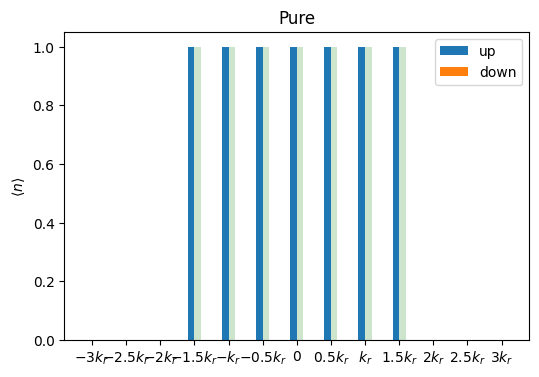

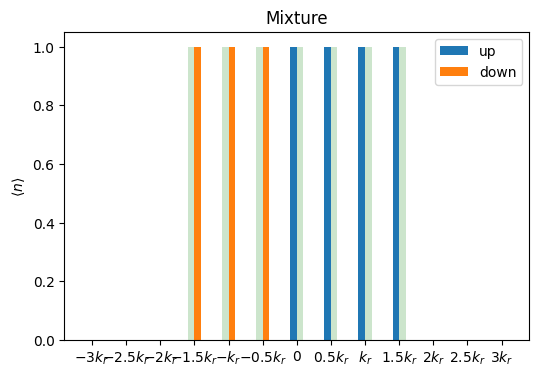

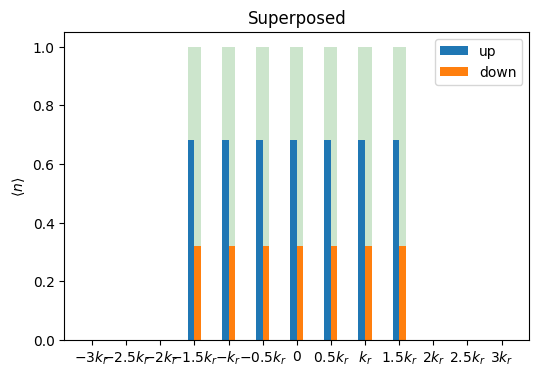

In [11]:
pure_nums, mixture_nums, superposed_nums = hilb.momentum_expected_numbers(np.stack([pure, mixture, superposed]))
plot_numbers(*pure_nums, tick_labels=k_tick_labels, title="Pure")
plot_numbers(*mixture_nums, tick_labels=k_tick_labels, title="Mixture")
plot_numbers(*superposed_nums, tick_labels=k_tick_labels, title="Superposed")

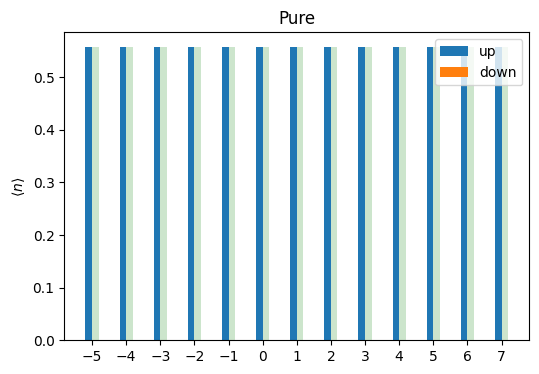

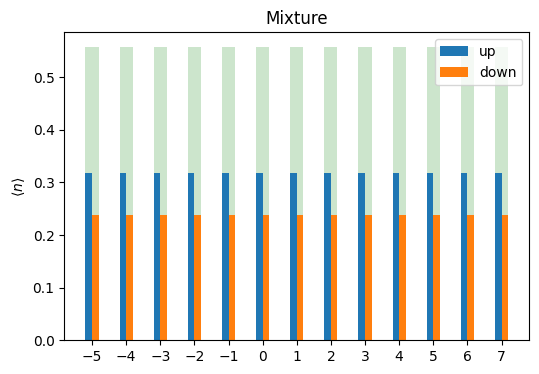

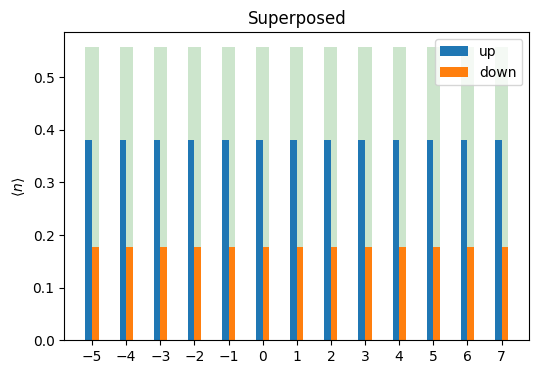

In [12]:
pure_nums, mixture_nums, superposed_nums = hilb.position_expected_numbers(np.stack([pure, mixture, superposed]))
plot_numbers(*pure_nums, title="Pure")
plot_numbers(*mixture_nums, title="Mixture")
plot_numbers(*superposed_nums, title="Superposed")

In [13]:
# initial_state = pure
# initial_state = mixture
initial_state = superposed

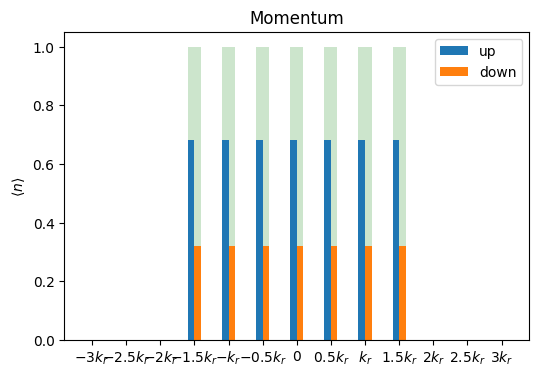

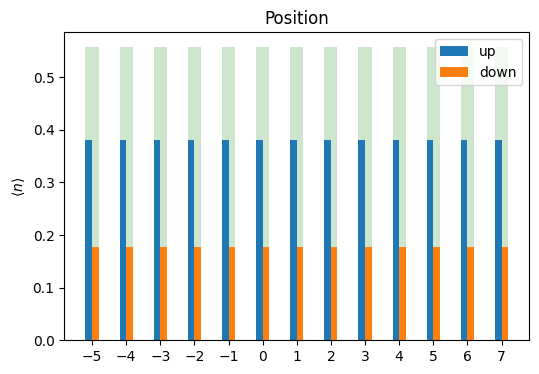

In [14]:
initial_nums = hilb.momentum_expected_numbers(initial_state)
plot_numbers(*initial_nums, tick_labels=k_tick_labels, title="Momentum")

initial_nums = hilb.position_expected_numbers(initial_state)
plot_numbers(*initial_nums, title="Position")

## Two-body loss simulation by quantum jump method

- Hamiltonians
\begin{gather}
H_{\text{free}}=\sum_{q_x, \sigma} \frac{\hbar^2 q_x^2}{2m_\mathrm{Yb}}c_{\sigma}^\dagger(q_x) c_{\sigma}(q_x),\\
H_{\text{loss}}=-\frac{i\gamma\hbar}{2V}\sum_{k, k', q} c_{\downarrow}^\dagger(k'+q) c_{\uparrow}^\dagger(k-q)c_{\uparrow}(k)c_{\downarrow}(k'),\\
\end{gather}


- Lindblad master equation
\begin{align}
\frac{d\rho}{dt} &=-\frac{i}{\hbar} [H_\text{free}, \rho] + \int dx \left(L_x\rho L_x^\dagger -\frac{1}{2}\{L_x^\dagger L_x,\rho\}\right)\\
&=-\frac{i}{\hbar} [H_\text{free}, \rho] + \sum_q \left(\tilde{L}_q\rho \tilde{L}_q^\dagger -\frac{1}{2}\{\tilde{L}_q^\dagger \tilde{L}_q,\rho\}\right)
\end{align}


Two-body loss channels:
\begin{equation}
	L_x=\sqrt{\gamma} c_{\uparrow}(x) c_{\downarrow}(x),\quad \tilde{L}_q=\sqrt{\frac{\gamma}{V}}\sum_{k_1+k_2=q}c_{\uparrow}(k_q) c_{\downarrow}(k_2)
\end{equation}



- Master equation with decoherence
\begin{equation}
	\frac{d\rho}{dt} =-\frac{i}{\hbar} [H_\text{free}, \rho] + \underbrace{\sum_q \left(\tilde{L}_q\rho \tilde{L}_q^\dagger -\frac{1}{2}\{\tilde{L}_q^\dagger \tilde{L}_q,\rho\}\right)}_{\text{two-body loss}} + \underbrace{\sum_{j=1}^{\dim \mathcal H}\left(M_j\rho M_j^\dagger - \frac{1}{2}\{M_j^\dagger M_j,\ \rho\}\right)}_{\text{decoherence}}
\end{equation}


Decoherence channels:
\begin{gather}
M_j=\sqrt{\frac{1}{T_2}}\ket{j}\bra{j} \quad(\ket{j}\in\mathcal{B}), \\
\mathcal{B}= \{c_{\sigma_1}^\dagger(k_1)c_{\sigma_2}^\dagger(k_2)\cdots c_{\sigma_n}^\dagger(k_n)\ket{0}:\sigma_j=\uparrow,\downarrow, k_1<k_2<\cdots<k_n, |k_j|<k_\text{cutoff}, k_j\in (2\pi / L) \mathbb Z\}
\end{gather}


- non-hermitian evolution part and jump part
\begin{equation}
	\frac{d\rho}{dt}=\underbrace{-\frac{i}{\hbar} [H_\text{eff}\rho - \rho H_\text{eff}^\dagger]}_{\text{non-hermitian evolution}} + \underbrace{\sum_{q} \tilde{L}_q\rho \tilde{L}_q^\dagger}_{\text{loss jumps}} + \underbrace{\sum_{j=1}^{\dim \mathcal H}M_j\rho M_j^\dagger}_{\text{decoherence jumps}}
\end{equation}


Effective hamiltonian:
\begin{equation}
    H=H_\text{free} + H_\text{loss} -\frac{i\hbar}{2T_2}
\end{equation}



- $T_2 = 0.4 \,\mathrm{ms}$

### simulation settings

In [15]:
t0 = 0
t1 = 3.0 / 0.1129
n_timesteps = 51
save_at = np.linspace(t0, t1, n_timesteps)
step_size = save_at[1] - save_at[0]

n_trajectories = 512
batch_size = 32
jumps_per_step = 4 # try 200 jump total

assert n_trajectories % batch_size == 0

In [16]:
num_batches = n_trajectories // batch_size
total_n_steps = (n_timesteps - 1) * jumps_per_step
delta_t = (t1 - t0) / total_n_steps

loss_channels = ybsoc.lindblad_two_body_loss_scipy_csr(
    hilb, gamma, reduced_rows=True
)
subspace_dim = hilb.space_dim - math.comb(hilb.num_single_particle_states, hilb.n_particles[-1])
n_loss_channels = len(loss_channels)
stacked_loss_op_scipy = scipy.sparse.vstack(loss_channels, format='csr')

del loss_channels
gc.collect()

hilb_dim = hilb.space_dim
H_eff_scipy = ybsoc.sparse_hamiltonian_scipy_csr(
    hilb,
    hbar=hbar,
    k_r=0.0,
    m_Yb=m_Yb,
    delta=0.0,
    omega_R=0.0,
    U=-(1/2) * 1j * gamma * hbar
)
H_eff_scipy = H_eff_scipy - (1j * hbar) / (2 * T2) * scipy.sparse.identity(hilb_dim, format='csr')

In [17]:
one_norm = scipy.sparse.linalg.onenormest(-1j * H_eff_scipy * delta_t / hbar)

In [18]:
norm_bound = 1.0
taylor_order = 8

# norm_bound = 0.5
# taylor_order = 5

In [19]:
from math import ceil
steps_for_expm = ceil(one_norm / norm_bound)
print("recommanded n_steps:", steps_for_expm)

recommanded n_steps: 6


In [20]:
@partial(jax.jit, static_argnums=(2,))
def expm_taylor(
    A: jsparse.JAXSparse,
    B: jax.Array,
    order: int
):
    """calculate and apply the matrix exponential

    compute $e^A B$ using a Taylor expansion of the matrix exponential.

    Args:
        A (jax.experimental.sparse.JAXSparse): Sparse matrix to calculate the matrix exponential.
        B (jax.Array): dense matrix to multiply the matrix exponential with.
        order (int): order of the Taylor expansion.
    """
    if order == 0:
        return B

    init_state = (B, B)

    def taylor_body(i, state):
        acc, carry = state
        carry = A @ carry / i
        acc = acc + carry
        return acc, carry

    final_val, _ = jax.lax.fori_loop(1, order + 1, taylor_body, init_state)
    return final_val


@partial(jax.jit, static_argnums=(2, 3))
def apply_expm(
    A_scaled: jsparse.JAXSparse,
    B: jax.Array,
    n_steps: int,
    taylor_order: int
):
    """apply the matrix exponential to a state
    compute $e^{A} B = (e^{A/n})^n B$

    Args:
        A (jax.experimental.sparse.JAXSparse): Sparse matrix to calculate the matrix exponential.
        B (jax.Array): dense matrix to multiply the matrix exponential with.
        n_steps (int): number of steps to apply the taylor polynomials.
        taylor_order (int): order of the Taylor expansion.
    """
    def step_body(i, state):
        return expm_taylor(A_scaled, state, taylor_order)

    exp_A_B = jax.lax.fori_loop(0, n_steps, step_body, B)
    return exp_A_B


@partial(jax.jit, static_argnames=('n_expm_steps', 'taylor_order'), donate_argnames=('psi_batched',))
def qjm_step(
    psi_batched: Complex[Array, "hdim batch"],
    scaled_exponent: jsparse.JAXSparse,
    stacked_loss_op: jsparse.JAXSparse,
    delta_t: Float[Array, ""],
    hbar: Float[Array, ""],
    n_expm_steps: int,
    taylor_order: int,
    *,
    key: PRNGKeyArray,
):
    # non-hermitian evolution
    psi_evolved = apply_expm(
        scaled_exponent, # (-1j * delta_t / hbar) * H_eff,
        psi_batched,
        n_steps=n_expm_steps,
        taylor_order=taylor_order
    )

    # apply loss operator
    loss_jumped = rearrange(
        stacked_loss_op @ psi_evolved,
        "(channels state) batch -> channels state batch",
        channels=n_loss_channels
    )

    loss_jump_probs = jnp.linalg.norm(loss_jumped, axis=1) ** 2 * delta_t # channels state batch -> channels batch
    dephase_jump_probs = (1 / T2) * (jnp.abs(psi_evolved) ** 2) * delta_t # (hdim, batch)
    no_jump_probs = 1 - (jnp.sum(loss_jump_probs, axis=0, keepdims=True) + jnp.sum(dephase_jump_probs, axis=0, keepdims=True))

    jump_probs, _ = pack(
        [loss_jump_probs, dephase_jump_probs, no_jump_probs],
        "* batch"
    )

    # determine jump channel
    key, subkey = jax.random.split(key)
    cum_p = jnp.cumsum(jump_probs, axis=0)                       # (C_total, B)
    rand = jax.random.uniform(subkey, (batch_size,))             # (B,)
    jump_indices = jax.vmap(
        lambda x, y: jnp.searchsorted(x, y, side="right"),
        in_axes=(1, 0)
    )(cum_p, rand)                                               # (B,)

    # apply jump
    def _apply_jump(psi, loss_jumped, jump_index):
        branch = jnp.where(jump_index < n_loss_channels,            0,
                 jnp.where(jump_index < n_loss_channels + hilb_dim, 1,
                                                                    2))
        def _loss(_):
            new = jnp.zeros_like(psi)
            new = new.at[:subspace_dim].set(loss_jumped[jump_index, :])
            norm = jnp.linalg.norm(new)
            return new / norm
        def _dephase(_):
            return jax.nn.one_hot(jump_index - n_loss_channels, hilb_dim, dtype=np.complex128)
        def _no_jump(_):
            norm = jnp.linalg.norm(psi)
            return psi / norm

        psi_new = jax.lax.switch(branch, [_loss, _dephase, _no_jump], None)
        return psi_new

    psi_jumped = jax.vmap(_apply_jump, in_axes=(1, 2, 0), out_axes=1)(
        psi_evolved,
        loss_jumped,
        jump_indices
    )
    return psi_jumped

momentum_num_op_diag = jnp.array(hilb.momentum_num_op_diags())

@jax.jit
def psis_to_momenum_nums(psi_batched: Complex[Array, "hdim batch"]):
    probs = jnp.abs(psi_batched) ** 2
    expected_numbers = einsum(momentum_num_op_diag, probs, "c hdim, hdim batch -> batch c")
    up_mom, down_mom = rearrange(expected_numbers, "batch (mom spin) -> spin batch mom", spin=2)
    return jnp.sum(up_mom, axis=0), jnp.sum(down_mom, axis=0)

In [21]:
scaled_exponent = jsparse.BCSR.from_scipy_sparse((-1j * delta_t / hbar) * H_eff_scipy / steps_for_expm)
stacked_loss_op = jsparse.BCSR.from_scipy_sparse(stacked_loss_op_scipy)

In [22]:
seed = 50
key = jax.random.key(seed)

In [ ]:
up_nums_momentum = np.zeros((n_timesteps, n_momentum_points))
down_nums_momentum = np.zeros((n_timesteps, n_momentum_points))
n_position_points = n_momentum_points
up_nums_position = np.zeros((n_timesteps, n_position_points))
down_nums_position = np.zeros((n_timesteps, n_position_points))

psi_batched = np.repeat(initial_state[:, np.newaxis], batch_size, axis=1) # prepare batched states
psi_batched = jnp.array(psi_batched, dtype=np.complex128) # convert to jax array


up_mom, down_mom = hilb.momentum_expected_numbers(initial_state)
up_nums_momentum[0, :] = up_mom * n_trajectories
down_nums_momentum[0, :] = down_mom * n_trajectories
up_pos, down_pos = hilb.position_expected_numbers(initial_state)
up_nums_position[0, :] = up_pos * n_trajectories
down_nums_position[0, :] = down_pos * n_trajectories


for i_batch in range(num_batches):

    psi_batched = np.repeat(initial_state[:, np.newaxis], batch_size, axis=1) # prepare batched states
    psi_batched = jnp.array(psi_batched, dtype=np.complex128) # convert to jax array
    psis = np.asarray(psi_batched).T # (n, b) => (b, n)


    for iteration in tqdm.trange(total_n_steps, desc=f"batch {i_batch}: {(i_batch+1) * batch_size}/{n_trajectories} Trajectories", leave=False):
        # start = time.time()
        key, subkey = jax.random.split(key)
        psi_batched = qjm_step(
            psi_batched,
            scaled_exponent,
            stacked_loss_op,
            delta_t=delta_t,
            hbar=hbar,
            n_expm_steps=steps_for_expm,
            taylor_order=taylor_order,
            key=subkey
        )
        # psi_batched.block_until_ready()
        # print("qjm step", time.time() - start)

        # start = time.time()
        # calculate obaservables
        if (iteration + 1) % jumps_per_step != 0:
            # print("obeservables 1", time.time() - start)
            continue

        i = (iteration + 1) // jumps_per_step

        # print("stamp 1", time.time() - start)
        up_num_sum, down_num_sum = psis_to_momenum_nums(psi_batched)
        # up_num_sum.block_until_ready()
        # down_num_sum.block_until_ready()
        # print("stamp 2", time.time() - start)

        up_nums_momentum[i, :] += np.asarray(up_num_sum)
        down_nums_momentum[i, :] += np.asarray(down_num_sum)
        # print("stamp 3", time.time() - start)

        if i < n_timesteps - 1:
            # print("obeservables 2", time.time() - start)
            continue

        psis = np.asarray(psi_batched).T # (n, b) => (b, n)
        nums = hilb.position_expected_numbers(psis)
        up_pos, down_pos = rearrange(nums, "b s x -> s b x")
        up_nums_position[i, :] += np.sum(up_pos, axis=0)
        down_nums_position[i, :] += np.sum(down_pos, axis=0)

        # print("obeservables 3", time.time() - start)

up_nums_momentum /= n_trajectories
down_nums_momentum /= n_trajectories
up_nums_position /= n_trajectories
down_nums_position /= n_trajectories

batch 0: 32/512 Trajectories:  14%|█▍        | 28/200 [05:13<31:59, 11.16s/it]

In [ ]:
total_up = np.sum(up_nums_momentum, axis=1)
total_down = np.sum(down_nums_momentum, axis=1)

fraction_up = total_up / n_particles
fraction_down = total_down / n_particles

## plot & save

In [ ]:
data_dir = os.path.join(DATA_ROOT, "data")
figs_dir = os.path.join(DATA_ROOT, "figs")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

In [ ]:
np.save(os.path.join(data_dir, "t.npy"), save_at)
np.save(os.path.join(data_dir, "total_up.npy"), total_up)
np.save(os.path.join(data_dir, "total_down.npy"), total_down)
np.save(os.path.join(data_dir, "fraction_up.npy"), fraction_up)
np.save(os.path.join(data_dir, "fraction_down.npy"), fraction_down)

with open(os.path.join(data_dir, "parameters.json"), "w+") as f:
    json.dump(
        {
            "k0": k0,
            "n_momentum_points": n_momentum_points,
            "L": L,
            "n_particles": n_particles,
            "hbar": hbar,
            "m_Yb": m_Yb,
            "soc": {
                "k_r": k_r,
                "delta": delta,
                "omega_R": omega_R,
            },
            "pa": {
                "gamma": gamma,
                "T2": T2 * t_r
            }
        },
        f,
        indent=4
    )

In [ ]:
# figure options
transparent = True
dpi = 300
save_options = {
    "transparent": transparent,
    "dpi": dpi
}

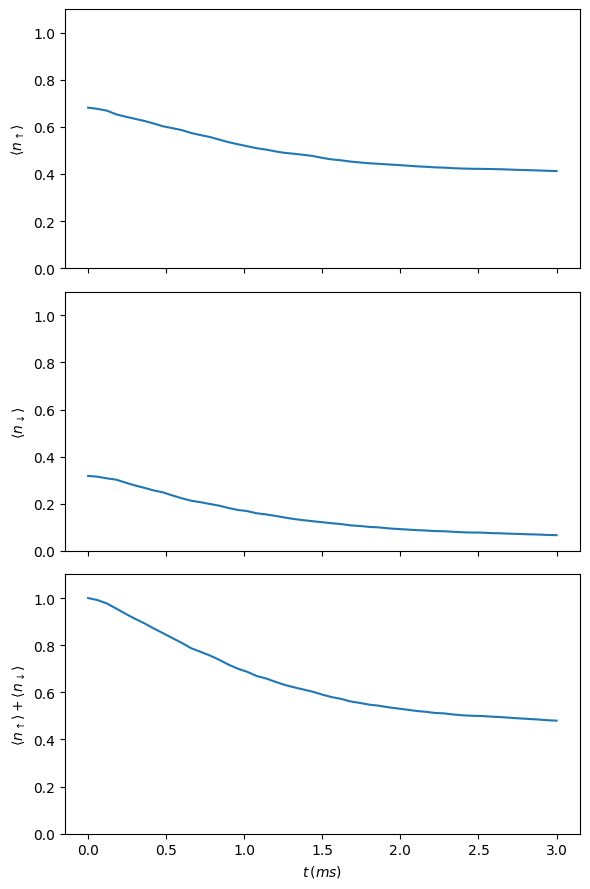

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 9))

ts = save_at * t_r
ax1.plot(ts, fraction_up)
ax1.set_ylabel("$\\langle n_{\\uparrow} \\rangle$")
ax1.set_ylim(0, 1.1)
# ax1.legend()

ax2.plot(ts, fraction_down)
ax2.set_ylabel("$\\langle n_{\\downarrow} \\rangle$")
ax2.set_ylim(0, 1.1)
# ax2.legend()


ax3.plot(ts, fraction_up + fraction_down)
ax3.set_ylabel("$\\langle n_{\\uparrow} \\rangle + \\langle n_{\\downarrow} \\rangle$")
ax3.set_ylim(0, 1.1)
# ax3.legend()
ax3.set_xlabel("$t\\,(ms)$")

plt.tight_layout()
fig_path = os.path.join(figs_dir, "total_number_time_evolution.png")
plt.savefig(fig_path, **save_options)
plt.show()

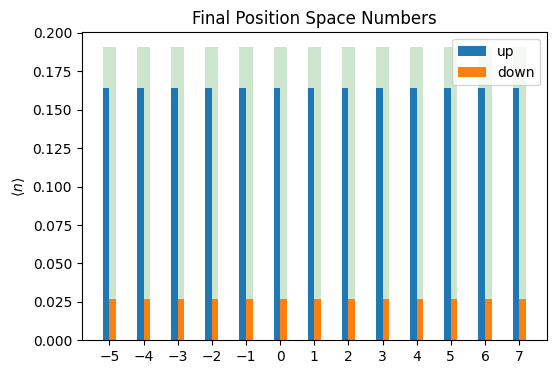

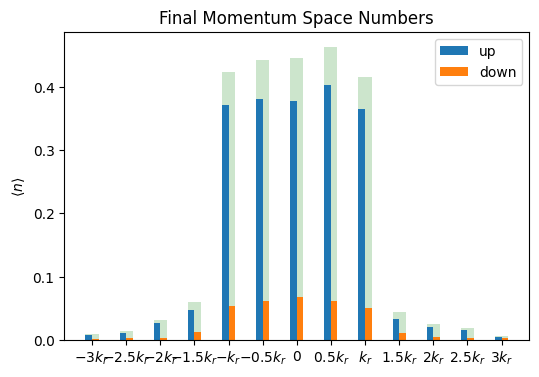

In [ ]:
final_position_nums_up = up_nums_position[-1]
final_position_nums_down = down_nums_position[-1]
final_momentum_nums_up = up_nums_momentum[-1]
final_momentum_nums_down = down_nums_momentum[-1]

np.save(os.path.join(data_dir, "final_position_numbers_up.npy"), final_position_nums_up)
np.save(os.path.join(data_dir, "final_position_numbers_down.npy"), final_position_nums_down)
np.save(os.path.join(data_dir, "total_momentum_numbers_up.npy"), final_momentum_nums_up)
np.save(os.path.join(data_dir, "total_momentum_numbers_down.npy"), final_momentum_nums_down)

fig_path = os.path.join(figs_dir, "final_position_numbers.png")
plot_numbers(
    final_position_nums_up,
    final_position_nums_down,
    title="Final Position Space Numbers",
    save_path=fig_path,
    save_options=save_options
)
fig_path = os.path.join(figs_dir, "total_momentum_numbers.png")
plot_numbers(
    final_momentum_nums_up,
    final_momentum_nums_down,
    tick_labels=k_tick_labels,
    title="Final Momentum Space Numbers",
    save_path=fig_path,
    save_options=save_options
)

In [ ]:
def plot_fractions(up_frac, down_frac, total_frac, tick_labels=None, title=None, save_path=None, save_options=None):
    L = total_frac.shape[0]
    indices = np.arange(L) - (L // 2 - 1)

    bar_width = ((6 - 1) / L) * 1.0 / 2

    plt.figure(figsize=(6, 4))

    plt.bar(indices, total_frac, width=2*bar_width, alpha=0.2, color='green')
    plt.bar(indices - bar_width/2, up_frac, bar_width, alpha=0.35, label='up')
    plt.bar(indices + bar_width/2, down_frac, bar_width, alpha=0.35, label='down')
    if tick_labels is not None:
        plt.xticks(indices, tick_labels)
    else:
        plt.xticks(indices)
    if title is not None:
        plt.title(title)
    else:
        plt.title("Fractions")
    plt.ylabel('$\\langle n\\rangle_\\text{final}/ \\langle n\\rangle_\\text{init}$')
    plt.ylim(-0.1, 1.1)
    plt.legend()
    if save_path is not None:
        if save_options is not None:
            plt.savefig(save_path, **save_options)
        else:
            plt.savefig(save_path)
    plt.show()

In [ ]:
def calc_loss_frac(initial, final):
    return np.where(np.abs(initial) < 1e-12, np.zeros_like(0), 1 - final / initial)

In [ ]:
initial_position_nums_up = up_nums_position[0]
initial_position_nums_down = down_nums_position[0]
initial_momentum_nums_up = up_nums_momentum[0]
initial_momentum_nums_down = down_nums_momentum[0]

/tmp/ipykernel_2916/1489670209.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.where(np.abs(initial) < 1e-12, np.zeros_like(0), 1 - final / initial)


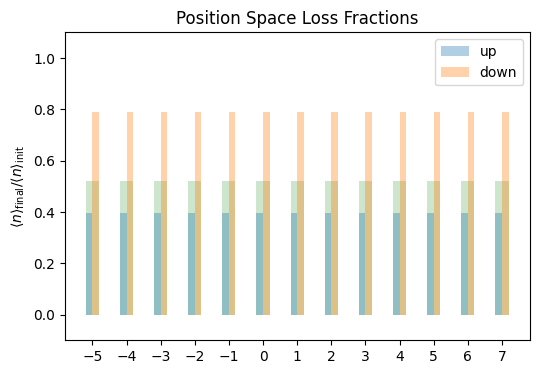

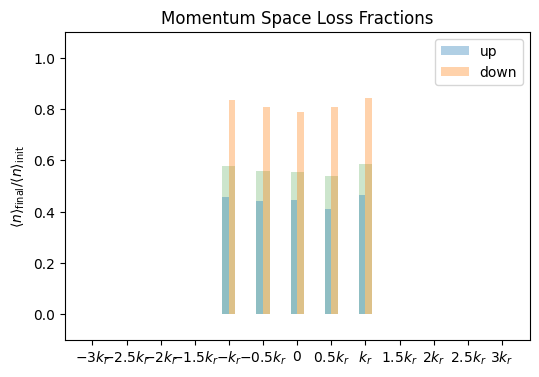

In [ ]:
initial_position_nums_total = initial_position_nums_up + initial_position_nums_down
initial_momentum_nums_total = initial_momentum_nums_up + initial_momentum_nums_down
final_position_nums_total = final_position_nums_up + final_position_nums_down
final_momentum_nums_total = final_momentum_nums_up + final_momentum_nums_down

loss_fraction_up_position = calc_loss_frac(initial_position_nums_up, final_position_nums_up)
loss_fraction_down_position = calc_loss_frac(initial_position_nums_down, final_position_nums_down)
loss_fraction_total_position = calc_loss_frac(initial_position_nums_total, final_position_nums_total)

loss_fraction_up_momentum = calc_loss_frac(initial_momentum_nums_up, final_momentum_nums_up)
loss_fraction_down_momentum = calc_loss_frac(initial_momentum_nums_down, final_momentum_nums_down)
loss_fraction_total_momentum = calc_loss_frac(initial_momentum_nums_total, final_momentum_nums_total)


fig_path = os.path.join(figs_dir, "position_space_loss_fraction.png")
plot_fractions(
    loss_fraction_up_position,
    loss_fraction_down_position,
    loss_fraction_total_position,
    title="Position Space Loss Fractions",
    save_path=fig_path,
    save_options=save_options
)

fig_path = os.path.join(figs_dir, "momentum_space_loss_fraction.png")
plot_fractions(
    loss_fraction_up_momentum,
    loss_fraction_down_momentum,
    loss_fraction_total_momentum,
    tick_labels=k_tick_labels,
    title="Momentum Space Loss Fractions",
    save_path=fig_path,
    save_options=save_options
)